# 02 - Results

Everything here is read from `results/` and `figures/`, which the scripts in `scripts/` regenerate. No number is typed in by hand.

Two real-data experiments and one simulation:
1. **Broad universe**: 2,720 resolved Polymarket binary markets, 57 fortnightly cohorts, ~11 bets per round. Selection uses only information available at each decision date.
2. **FOMC pairs**: 63 equivalent Polymarket/Kalshi contracts on 20 meetings (cross-venue detection, 1-3 bets per round).
3. **Simulation** with known ground truth, to isolate what robust Kelly does.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option('display.width', 200)
from IPython.display import Image, display
R = ROOT / 'results'
F = ROOT / 'figures'

## 1. Broad universe: is a market price already a good probability?

In [2]:
pd.read_csv(R / 'universe_calibration.csv').round(4)

,method,n,events,brier,ece,log_loss,brier_gain_lo,brier_gain_hi
0,raw,2623,1968,0.1656,0.0259,0.4974,NaN,NaN
1,platt,2623,1968,0.1664,0.0245,0.5003,-0.0015,-0.0001
2,isotonic,2623,1968,0.1683,0.0401,0.5164,-0.0041,-0.0011


`brier_gain_*` is the 90% event-cluster bootstrap interval of `Brier(raw) - Brier(method)`. A positive value would mean the calibrator helps. Both intervals lie below zero: recalibrating hurts out of time.

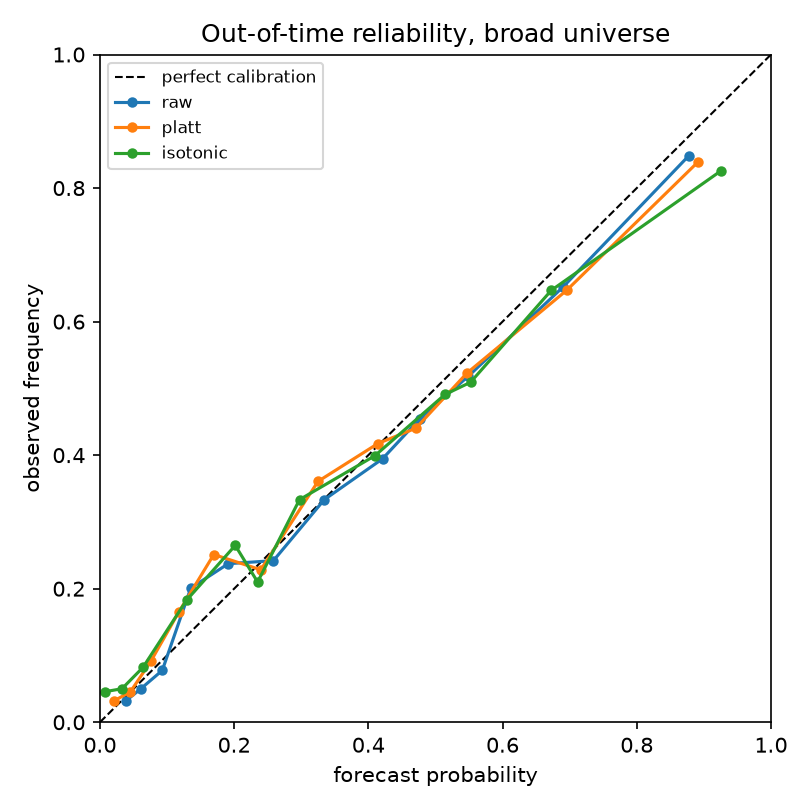

In [3]:
display(Image(F / 'universe_reliability.png', width=430))

## 2. Broad universe: allocation backtest

In [4]:
pd.read_csv(R / 'universe_bets_overall.csv').round(3)

,bets,events,share_yes,mean_price,mean_p_hat,win_rate,mean_roi,roi_lo,roi_hi
0,524,522,0.229,0.616,0.642,0.622,0.015,-0.058,0.088


In [5]:
pd.read_csv(R / 'universe_backtest.csv', index_col=0)[['cum_log_growth', 'final_wealth', 'max_drawdown', 'sharpe_like', 'frac_rounds_positive', 'worst_round']].round(3)

,cum_log_growth,final_wealth,max_drawdown,sharpe_like,frac_rounds_positive,worst_round
naive_kelly,0.005,1.005,0.261,0.005,0.469,-0.225
robust_G0,-0.022,0.979,0.263,-0.020,0.449,-0.225
robust_G1,-0.381,0.683,0.450,-0.366,0.388,-0.221
robust_G2,-0.117,0.890,0.256,-0.155,0.347,-0.161
robust_G3,-0.084,0.919,0.226,-0.124,0.327,-0.161
robust_G5,-0.094,0.911,0.259,-0.142,0.286,-0.161
robust_G8,-0.196,0.822,0.232,-0.361,0.143,-0.161
equal_weight,0.097,1.102,0.667,0.046,0.510,-0.300
random,-0.158,0.854,0.580,-0.106,0.510,-0.226


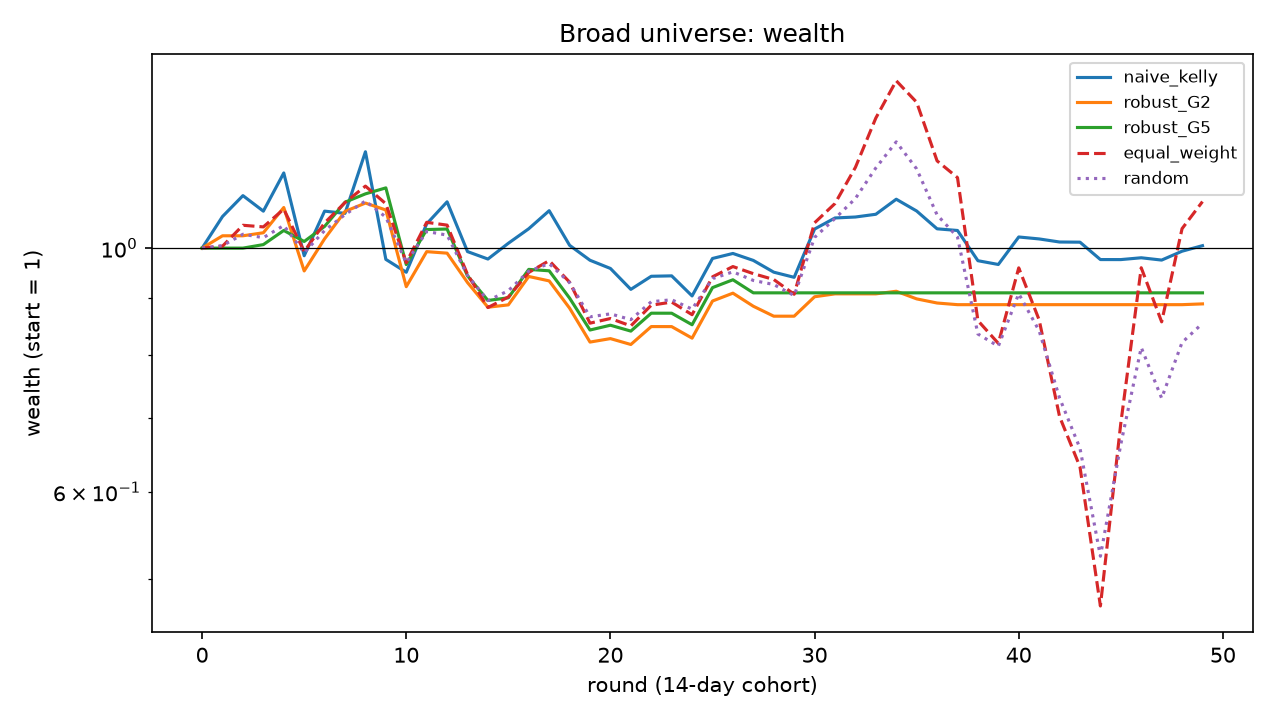

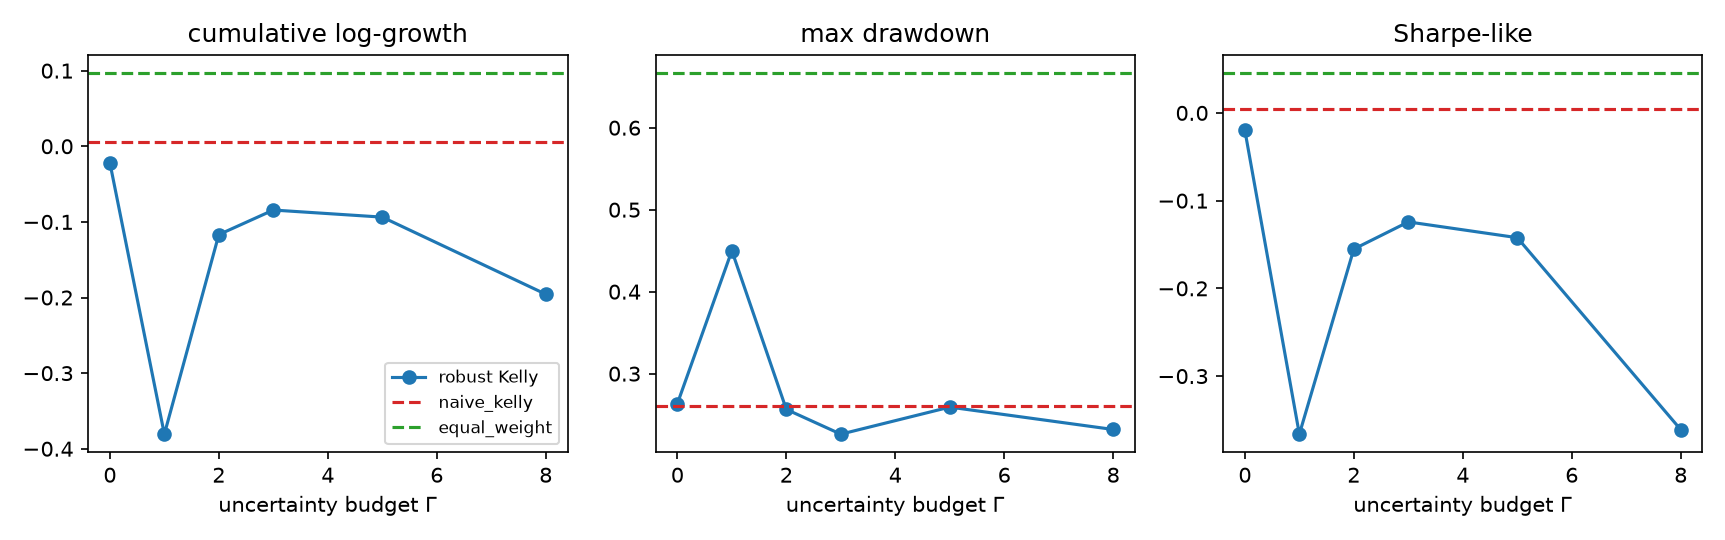

In [6]:
display(Image(F / 'universe_wealth.png')); display(Image(F / 'universe_gamma.png'))

### Are the differences real? Paired bootstrap over rounds (a - b)

In [7]:
pd.read_csv(R / 'universe_paired_bootstrap.csv').round(3)

,a,b,observed,lo,hi,prob_positive
0,naive_kelly,equal_weight,-0.092,-1.376,1.146,0.455
1,naive_kelly,random,0.163,-0.757,1.060,0.617
2,robust_G1,naive_kelly,-0.386,-0.825,0.026,0.062
3,robust_G2,naive_kelly,-0.122,-0.670,0.457,0.353
4,robust_G3,naive_kelly,-0.089,-0.680,0.552,0.398
5,robust_G5,naive_kelly,-0.099,-0.734,0.604,0.392
6,robust_G8,naive_kelly,-0.201,-0.866,0.526,0.315
7,robust_G1,equal_weight,-0.478,-1.783,0.808,0.279
8,robust_G2,equal_weight,-0.214,-1.520,1.050,0.396
9,robust_G3,equal_weight,-0.182,-1.479,1.102,0.414


In [8]:
pd.read_csv(R / 'universe_paired_bootstrap_risk.csv').round(3)

,a,b,statistic,observed,lo,hi,prob_positive
0,robust_G3,naive_kelly,max_drawdown,-0.034,-0.339,0.145,0.248
1,robust_G3,naive_kelly,sharpe_like,-0.129,-0.784,0.528,0.379
2,robust_G5,naive_kelly,max_drawdown,-0.001,-0.365,0.151,0.249
3,robust_G5,naive_kelly,sharpe_like,-0.147,-0.860,0.604,0.371
4,robust_G3,equal_weight,max_drawdown,-0.441,-0.564,-0.006,0.045
5,robust_G3,equal_weight,sharpe_like,-0.170,-0.900,0.670,0.388
6,robust_G5,equal_weight,max_drawdown,-0.408,-0.575,-0.008,0.045
7,robust_G5,equal_weight,sharpe_like,-0.188,-0.896,0.669,0.389


### Sensitivity (cumulative log-growth)

In [9]:
s = pd.read_csv(R / 'universe_sensitivity.csv')
s.pivot(index='strategy', columns='variant', values='cum_log_growth').round(2)

variant,active_40changes,bootstrap_intervals,budget_0.2,burn_in_12,burn_in_4,cost_0.5c,cost_2c,cost_3c,cost_5c,fresh_3h,isotonic,max_bets_20,max_bets_6,min_edge_2c,several_per_event,weak_prior
strategy,,,,,,,,,,,,,,,,
equal_weight,-2.32,0.10,0.12,0.02,0.20,0.61,-0.26,-0.33,-0.30,-0.85,-0.19,-0.41,0.81,-0.11,0.17,-0.25
naive_kelly,-1.22,0.01,0.07,-0.15,-0.12,0.25,-0.13,-0.36,-0.33,-0.58,0.40,-0.33,-0.09,-0.08,-0.08,-0.03
random,-1.81,-0.25,-0.01,-0.19,-0.28,0.17,-0.31,-0.29,-0.26,-0.90,-0.47,-0.79,0.28,-0.15,-0.19,-0.51
robust_G0,-1.24,-0.02,0.07,-0.18,-0.14,0.24,-0.13,-0.35,-0.33,-0.59,0.43,-0.34,-0.11,-0.09,-0.09,-0.04
robust_G2,-0.74,-0.03,-0.06,-0.20,-0.13,0.03,-0.18,-0.27,-0.23,-0.28,-0.57,-0.40,-0.28,-0.14,-0.16,-0.12
robust_G5,-0.24,-0.15,-0.06,-0.13,-0.09,-0.10,-0.20,-0.22,-0.00,-0.14,-0.03,-0.15,-0.08,-0.15,-0.05,-0.09


Robust Kelly minus naive Kelly per variant, with a 90% paired-bootstrap interval:

In [10]:
pd.read_csv(R / 'universe_sensitivity_paired.csv').round(3)

,variant,a,b,observed,lo,hi,prob_positive
0,cost_0.5c,robust_G2,naive_kelly,-0.219,-0.797,0.407,0.277
1,cost_0.5c,robust_G5,naive_kelly,-0.350,-1.050,0.394,0.212
2,cost_2c,robust_G2,naive_kelly,-0.049,-0.554,0.495,0.448
3,cost_2c,robust_G5,naive_kelly,-0.075,-0.670,0.579,0.434
4,cost_3c,robust_G2,naive_kelly,0.089,-0.406,0.632,0.622
5,cost_3c,robust_G5,naive_kelly,0.139,-0.462,0.803,0.640
6,cost_5c,robust_G2,naive_kelly,0.103,-0.431,0.697,0.604
7,cost_5c,robust_G5,naive_kelly,0.324,-0.223,0.960,0.816
8,min_edge_2c,robust_G2,naive_kelly,-0.053,-0.570,0.500,0.444
9,min_edge_2c,robust_G5,naive_kelly,-0.063,-0.621,0.570,0.438


## 3. Simulation: the price of robustness (known ground truth)

In [11]:
sim = pd.read_csv(R / 'simulation_summary.csv')
sim.pivot(index='strategy', columns='k_bad', values='mean').round(4)

k_bad,0,1,2,4
strategy,,,,
equal_weight,0.0626,0.0601,0.0640,0.0605
naive_kelly,0.0689,0.0536,0.0457,0.0460
oracle_kelly,0.0728,0.0708,0.0738,0.0700
robust_G0,0.0688,0.0535,0.0455,0.0460
robust_G1,0.0647,0.0641,0.0605,0.0545
robust_G2,0.0543,0.0605,0.0659,0.0579
robust_G3,0.0386,0.0502,0.0618,0.0610
robust_G6,0.0151,0.0250,0.0374,0.0506


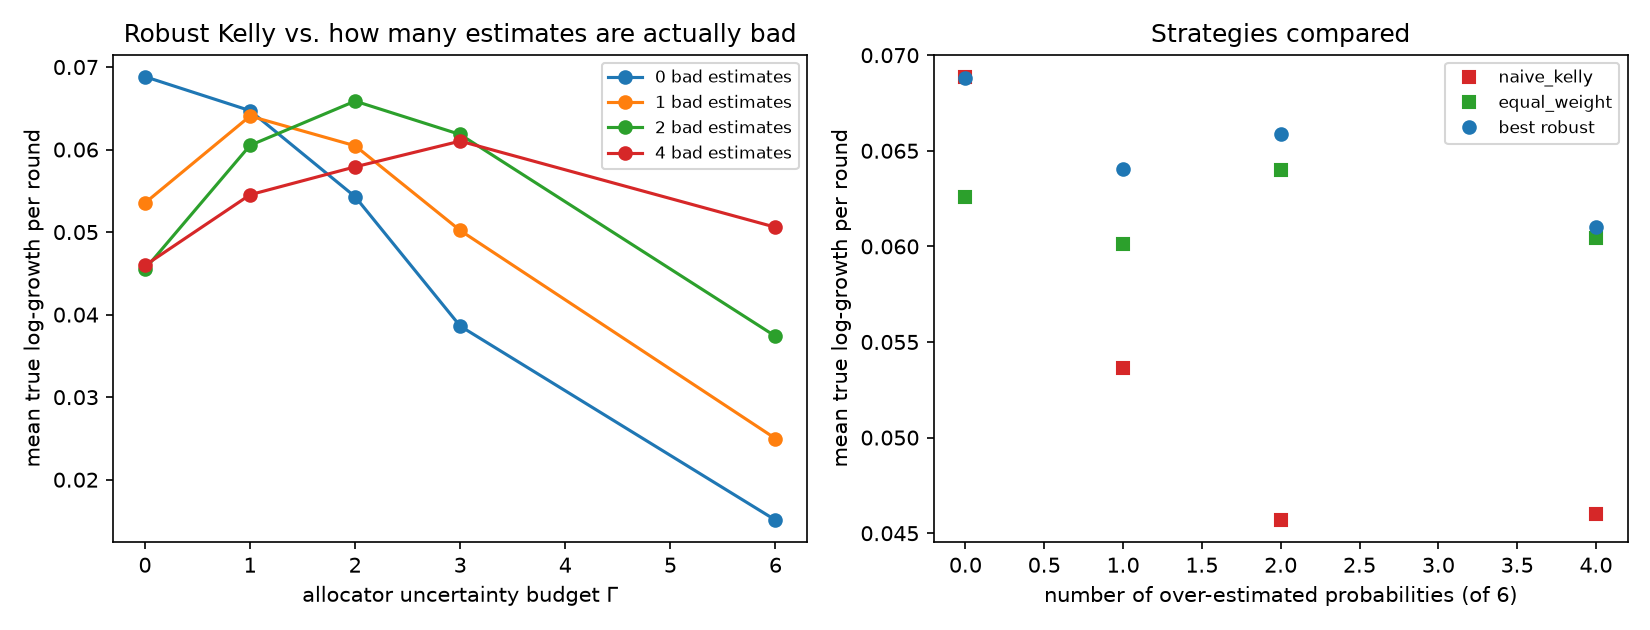

In [12]:
display(Image(F / 'simulation_gamma.png'))

## 4. FOMC cross-venue study

In [13]:
pd.read_csv(R / 'decision_time_divergence.csv').round(4)

,pairs,mean_abs_div,median_abs_div,pairs_ge_2c
0,61,0.0065,0.0045,4


In [14]:
pd.read_csv(R / 'anomaly_persistence.csv').round(3)

,detector,flag,n,persistent_rate
0,if_flag,False,294,0.711
1,if_flag,True,2,0.000
2,price_signal,False,272,0.721
3,price_signal,True,24,0.542
4,liquidity_signal,False,43,0.465
5,liquidity_signal,True,253,0.747
6,consensus,False,278,0.712
7,consensus,True,18,0.611


In [15]:
cal = pd.read_csv(R / 'calibration_metrics.csv')
cal[cal.venue == 'pooled'].round(4)

,venue,method,n,n_meetings,brier,ece,log_loss
8,pooled,raw,246,20,0.0091,0.0146,0.0456
9,pooled,platt_weak_prior,246,20,0.0018,0.0003,0.0078
10,pooled,platt,246,20,0.0049,0.0003,0.0185
11,pooled,isotonic,246,20,0.0049,0.0047,0.0207


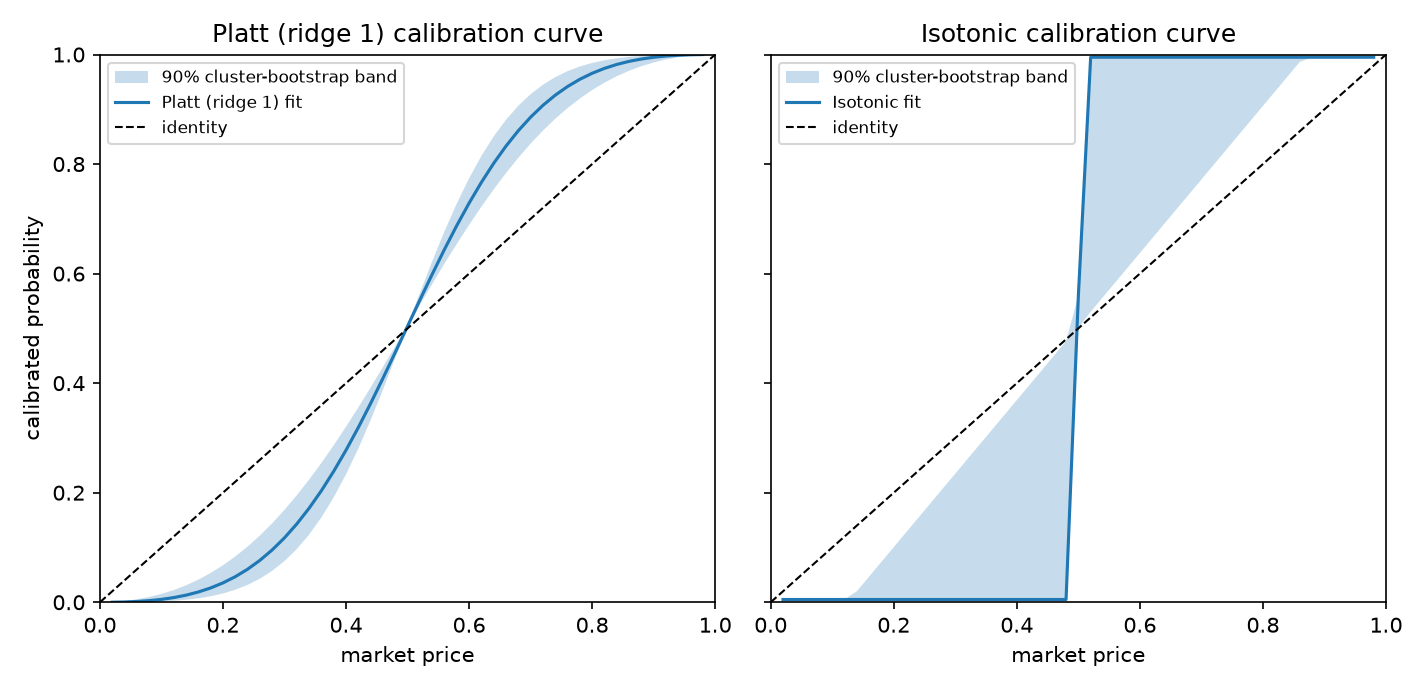

In [16]:
display(Image(F / 'calibration_bootstrap_band.png'))

In [17]:
pd.read_csv(R / 'backtest_primary.csv', index_col=0)[['cum_log_growth', 'final_wealth', 'max_drawdown', 'frac_rounds_positive']].round(3)

,cum_log_growth,final_wealth,max_drawdown,frac_rounds_positive
naive_kelly,0.296,1.344,0.0,0.571
robust_G0,0.296,1.344,0.0,0.571
robust_G0.5,0.050,1.051,0.0,0.143
robust_G1,0.000,1.000,0.0,0.000
robust_G2,0.000,1.000,0.0,0.000
robust_G3,0.000,1.000,0.0,0.000
robust_G5,0.000,1.000,0.0,0.000
equal_weight,0.293,1.340,0.0,0.571
random,0.190,1.209,0.0,0.571


The FOMC backtest earns its return by buying near-certain favourites (all won), which is carry, not evidence of an edge; see the README.